# Cuaderno 02 · Explicaciones locales post-hoc: SHAP y LIME

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 2 de 10

> Cuaderno reproducible asociado al artículo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

Este cuaderno formaliza y compara los dos métodos dominantes de explicación local *post-hoc*: **LIME** (Ribeiro, Singh & Guestrin, 2016) y **SHAP** (Lundberg & Lee, 2017). Para cada uno se deriva su fundamento matemático, se aplica sobre un modelo de *scoring* crediticio y se evalúan fidelidad, estabilidad y garantías formales.

El marco común es la **atribución aditiva de características**: dada una predicción $f(x)$, se busca descomponerla como

$$ f(x) \;=\; \phi_0 + \sum_{i=1}^{M} \phi_i , $$

donde $\phi_i$ es la contribución de la variable $i$ y $\phi_0$ un término base. LIME y SHAP son dos procedimientos distintos para estimar esos coeficientes, con propiedades teóricas diferentes que el cuaderno precisa.

## Contenido

| Sección | Tema | Resultado central |
|---|---|---|
| 0 | Modelo de referencia (XGBoost) sobre German Credit | caja negra a explicar |
| 1 | Atribución aditiva de características | $g(z')=\phi_0+\sum\phi_i z'_i$ |
| 2 | LIME: sustituto lineal local | $\xi(x)=\arg\min_g \mathcal L(f,g,\pi_x)+\Omega(g)$ |
| 3 | SHAP: valores de Shapley | fórmula de Shapley, axiomas, KernelSHAP, TreeSHAP |
| 4 | Comparación SHAP–LIME | garantías, estabilidad, costo |
| 5 | Alcance y límite causal | atribución observacional ≠ efecto causal |

**Salidas gráficas:** contribuciones LIME · dispersión de estabilidad de LIME · *waterfall* SHAP · *beeswarm* global · gráfico de dependencia SHAP · comparación SHAP–LIME.

**Objetivos.** (i) Derivar la formulación de LIME como mínimos cuadrados ponderados y la de SHAP a partir de los axiomas de Shapley; (ii) verificar empíricamente la aditividad exacta de SHAP; (iii) cuantificar la inestabilidad de LIME; (iv) precisar por qué una atribución fiel al modelo no constituye una afirmación causal.

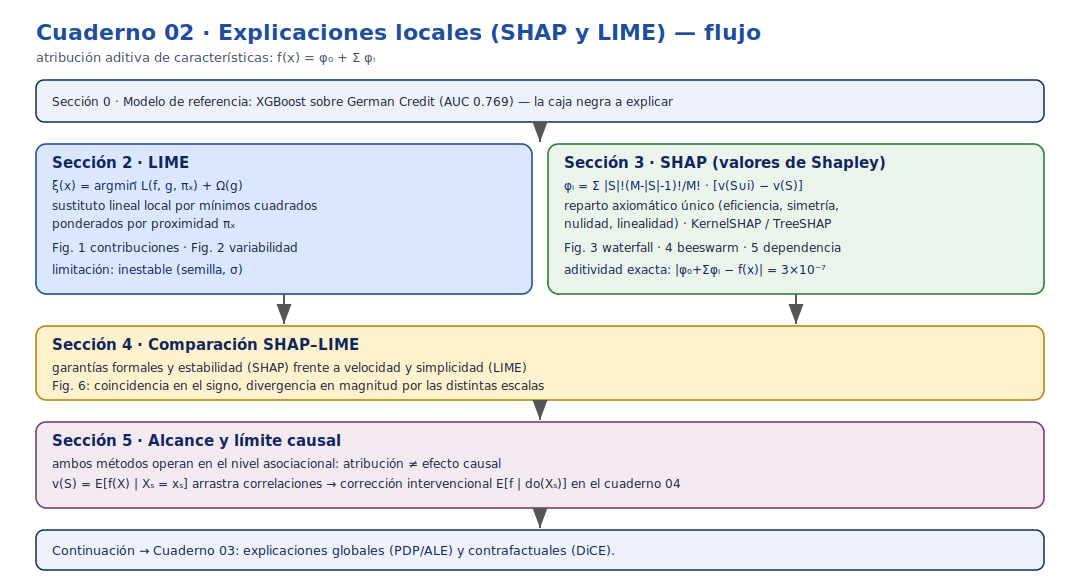

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/02_flujo.svg')
if not _svg.exists():
    _svg = Path('img/02_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Sección 0 · Modelo de referencia (caja negra) sobre German Credit
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_german_credit

import shap
import lime, lime.lime_tabular
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

df = load_german_credit()
y = df["riesgo_bueno"]
X = pd.get_dummies(df.drop(columns=["riesgo", "riesgo_bueno", "estado_personal_sexo"]),
                   drop_first=True).astype(float)
# XGBoost no admite nombres con < > [ ] : se sanean conservando legibilidad
import re
X.columns = [re.sub(r"_+", "_", re.sub(r"[^0-9A-Za-zÀ-ſ_]", "_", c)).strip("_")
             for c in X.columns]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

model = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                      subsample=0.9, eval_metric="logloss", random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]
print(f"AUC (XGBoost): {roc_auc_score(y_te, proba):.3f}")
print(f"{X.shape[1]} variables · {X_te.shape[0]} casos de prueba")

AUC (XGBoost): 0.769
46 variables · 300 casos de prueba


## Sección 1 · Atribución aditiva de características

Explicar **localmente** una predicción $f(x)$ consiste en cuantificar la contribución de cada variable al valor predicho en ese caso particular. Se formaliza mediante un modelo de explicación **aditivo** definido sobre variables binarias de presencia $z'\in\{0,1\}^M$ (1 = la variable toma su valor real; 0 = ausente):

$$ g(z') \;=\; \phi_0 + \sum_{i=1}^{M} \phi_i\, z'_i . $$

Se exige consistencia con el modelo cuando todas las variables están presentes: $g(\mathbf 1)=f(x)$. El problema es determinar los $\phi_i$ de manera que el reparto sea fiel y, deseablemente, único. LIME estima esos coeficientes ajustando un modelo lineal en un entorno de $x$; SHAP los define mediante el reparto axiomático de Shapley. Las dos secciones siguientes desarrollan cada enfoque.

> **Definición 1.1 (atribución aditiva de características).** Una *explicación aditiva* de la predicción $f(x)$ es un modelo lineal sobre variables binarias de presencia $z'\in\{0,1\}^M$,
> $$ g(z')=\phi_0+\sum_{i=1}^M \phi_i\,z'_i, \qquad g(\mathbf 1)=f(x), $$
> cuyos coeficientes $\phi_i$ son las **atribuciones**. LIME y SHAP son dos maneras de estimarlos, con propiedades distintas.

### Lectura geométrica de la descomposición

La descomposición aditiva se lee como un puente: se parte del valor base $\phi_0=\mathbb E[f(X)]$ y cada variable suma o resta hasta alcanzar $f(x)$. El siguiente esquema lo ilustra con valores ilustrativos; más adelante se obtiene con los valores reales (el *waterfall* de SHAP).

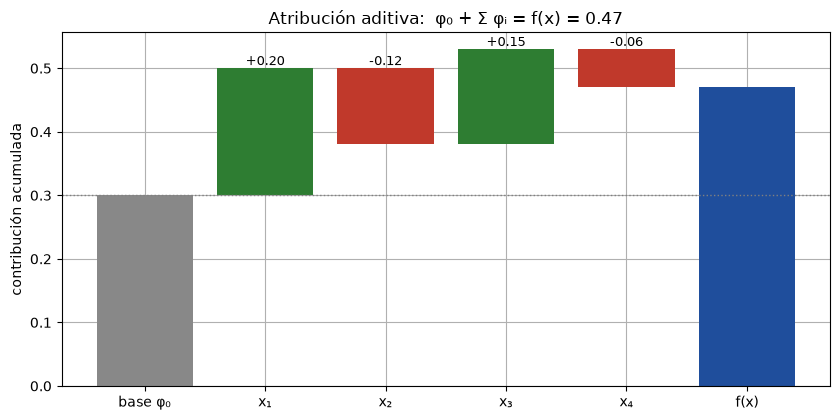

In [3]:
# Figura · esquema de atribución aditiva (valores ilustrativos)
phi0 = 0.30
contrib = {"x₁": +0.20, "x₂": -0.12, "x₃": +0.15, "x₄": -0.06}
fx = phi0 + sum(contrib.values())
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar("base φ₀", phi0, color="#888888")
acum = phi0
for k, v in contrib.items():
    ax.bar(k, abs(v), bottom=min(acum, acum + v), color="#2e7d32" if v > 0 else "#c0392b")
    ax.text(k, max(acum, acum + v) + 0.005, f"{v:+.2f}", ha="center", fontsize=9)
    acum += v
ax.bar("f(x)", fx, color="#1f4e9c")
ax.axhline(phi0, ls=":", color="gray", lw=1)
ax.set_ylabel("contribución acumulada")
ax.set_title(f"Atribución aditiva:  φ₀ + Σ φᵢ = f(x) = {fx:.2f}")
plt.tight_layout(); plt.show()

## Sección 2 · LIME (*Local Interpretable Model-agnostic Explanations*)

Aunque $f$ sea globalmente no lineal, en un entorno reducido de $x$ admite una aproximación lineal. LIME (Ribeiro et al., 2016) construye esa aproximación a partir de muestras perturbadas alrededor de $x$, ponderadas por su cercanía. La explicación es la solución de

$$ \xi(x) \;=\; \arg\min_{g\in G}\; \underbrace{\mathcal L\big(f, g, \pi_x\big)}_{\text{infidelidad local}} \;+\; \underbrace{\Omega(g)}_{\text{complejidad}} , $$

con los siguientes componentes:

- **Familia $G$**: modelos lineales dispersos.
- **Proximidad $\pi_x$**: núcleo exponencial $\pi_x(z)=\exp\!\big(-D(x,z)^2/\sigma^2\big)$, que asigna mayor peso a las muestras $z$ próximas a $x$ (ancho de banda $\sigma$).
- **Pérdida** $\mathcal L$: error cuadrático **ponderado** sobre las perturbaciones,
$$ \mathcal L = \sum_{z} \pi_x(z)\,\big(f(z) - g(z')\big)^2 . $$
- **Complejidad** $\Omega$: restricción a $K$ variables (selección / LASSO).

La componente lineal tiene solución cerrada: es una **regresión por mínimos cuadrados ponderados**,
$$ \hat\phi = (Z^\top W Z)^{-1} Z^\top W\, f(Z), \qquad W=\mathrm{diag}(\pi_x). $$

> **Definición 2.1 (explicación LIME).** Dada una familia interpretable $G$, un núcleo de proximidad $\pi_x$ y una penalización de complejidad $\Omega$, la explicación LIME de $x$ es
> $$ \xi(x)=\arg\min_{g\in G}\ \mathcal L(f,g,\pi_x)+\Omega(g),\qquad \mathcal L(f,g,\pi_x)=\sum_{z}\pi_x(z)\big(f(z)-g(z')\big)^2. $$

> **Proposición 2.1 (LIME lineal = mínimos cuadrados ponderados).** Si $G$ son los modelos lineales $g(z')=Z\phi$ —con $Z$ la matriz de diseño cuyas filas son $[1,\ z'^\top]$— y se omite $\Omega$, el minimizador es la solución de mínimos cuadrados **ponderados**
> $$ \hat\phi=(Z^\top W Z)^{-1}Z^\top W\,\mathbf f, \qquad W=\mathrm{diag}\big(\pi_x(z)\big),\quad \mathbf f=(f(z))_z. $$
>
> **Demostración.** Con $g(Z)=Z\phi$, la pérdida es la forma cuadrática $\mathcal L(\phi)=(\mathbf f-Z\phi)^\top W(\mathbf f-Z\phi)$, convexa en $\phi$ porque $W\succeq 0$. Su gradiente es $\nabla_\phi\mathcal L=-2\,Z^\top W(\mathbf f-Z\phi)$. Igualando a cero se obtienen las **ecuaciones normales ponderadas** $Z^\top W Z\,\phi=Z^\top W\,\mathbf f$; si $Z^\top W Z$ es invertible, $\hat\phi=(Z^\top W Z)^{-1}Z^\top W\,\mathbf f$. $\blacksquare$
>
> **Observación 2.1.** La explicación de LIME es entonces una **regresión lineal local**, ponderada por la cercanía a $x$. Su dependencia del núcleo $\pi_x$ y del muestreo de perturbaciones explica la inestabilidad que se cuantifica más abajo.

### La intuición geométrica de LIME

Para ver qué hace LIME, se aplica a un problema **bidimensional** con frontera no lineal (donde todo es visualizable). Se generan perturbaciones alrededor del punto $x$ a explicar, ponderadas por el núcleo de proximidad $\pi_x$ (tamaño y tono de los puntos), y se ajusta un **modelo lineal ponderado**. Su frontera —la línea punteada— es la explicación local: aproxima bien la frontera real **cerca** de $x$ y mal lejos. De ahí el carácter estrictamente *local* del método.

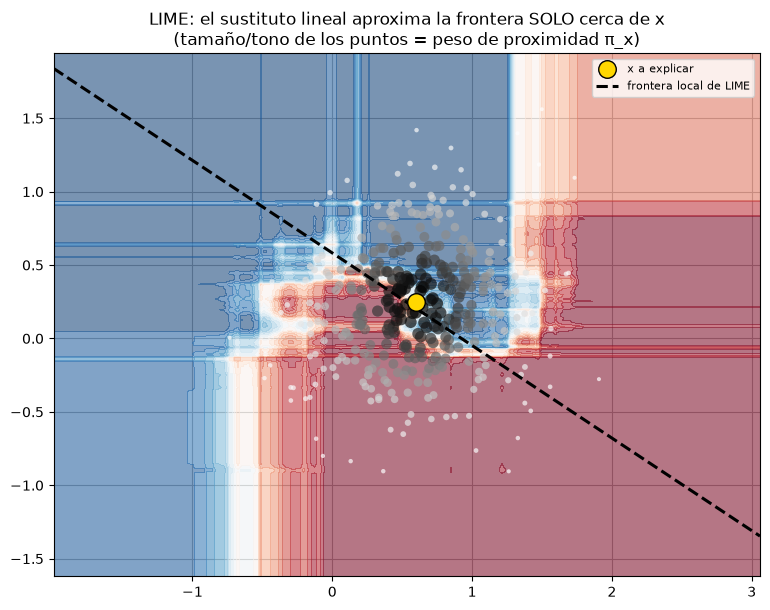

In [4]:
# Figura · LIME como sustituto lineal local en un problema 2D
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.linear_model import LinearRegression as _LinReg

Xm, ym = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)
clf2d = _RFC(n_estimators=200, random_state=RANDOM_STATE).fit(Xm, ym)

x_star = np.array([0.6, 0.25])                      # punto a explicar
gx, gy = np.meshgrid(np.linspace(Xm[:, 0].min()-.6, Xm[:, 0].max()+.6, 250),
                     np.linspace(Xm[:, 1].min()-.6, Xm[:, 1].max()+.6, 250))
Zg = clf2d.predict_proba(np.c_[gx.ravel(), gy.ravel()])[:, 1].reshape(gx.shape)

sigma = 0.45
Pert = x_star + rng.normal(0, sigma, size=(350, 2))
fP = clf2d.predict_proba(Pert)[:, 1]
wP = np.exp(-(((Pert - x_star) ** 2).sum(1)) / (2 * sigma ** 2))   # proximidad π_x
lin = _LinReg().fit(Pert, fP, sample_weight=wP)                    # sustituto lineal ponderado
a, (b1, b2) = lin.intercept_, lin.coef_

fig, ax = plt.subplots(figsize=(7.8, 6.2))
cs = ax.contourf(gx, gy, Zg, levels=20, cmap="RdBu_r", alpha=.55)
ax.scatter(Pert[:, 0], Pert[:, 1], s=8 + 70 * wP, c=wP, cmap="Greys", alpha=.7, edgecolor="none")
ax.scatter(*x_star, color="gold", edgecolor="k", s=160, zorder=6, label="x a explicar")
xs = np.linspace(gx.min(), gx.max(), 50)
ax.plot(xs, (0.5 - a - b1 * xs) / b2, "k--", lw=2.2, label="frontera local de LIME")
ax.set_xlim(gx.min(), gx.max()); ax.set_ylim(gy.min(), gy.max())
ax.set_title("LIME: el sustituto lineal aproxima la frontera SOLO cerca de x\n"
             "(tamaño/tono de los puntos = peso de proximidad π_x)")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

In [5]:
# Explicador LIME ajustado sobre el conjunto de entrenamiento
feat = list(X.columns)
expl_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_tr.values, feature_names=feat,
    class_names=["malo", "bueno"], mode="classification",
    discretize_continuous=True, random_state=RANDOM_STATE)

# Caso de prueba más cercano a la frontera de decisión (prob ≈ 0.5)
idx = int(np.argmin(np.abs(proba - 0.5)))
x0 = X_te.iloc[idx]
exp = expl_lime.explain_instance(x0.values, model.predict_proba, num_features=10)

print(f"Caso de prueba #{idx} · prob. de buen pagador = {proba[idx]:.2f}")
print("Contribuciones locales (LIME):")
for f, w in exp.as_list():
    print(f"  {w:+.3f}   {f}")

Caso de prueba #289 · prob. de buen pagador = 0.50
Contribuciones locales (LIME):
  -0.223   proposito_carro_usado <= 0.00
  +0.138   duracion_meses <= 12.00
  -0.134   otros_deudores_A103 <= 0.00
  +0.124   2290.00 < monto_credito <= 3965.25
  -0.120   proposito_radio_TV <= 0.00
  +0.101   0.00 < historial_credito_crítica_otros_créditos <= 1.00
  -0.099   3.00 < residencia_desde <= 4.00
  -0.095   ahorros_1000_DM <= 0.00
  +0.093   0.00 < estado_cuenta_sin_cuenta <= 1.00
  -0.083   0.00 < ahorros_100_DM <= 1.00


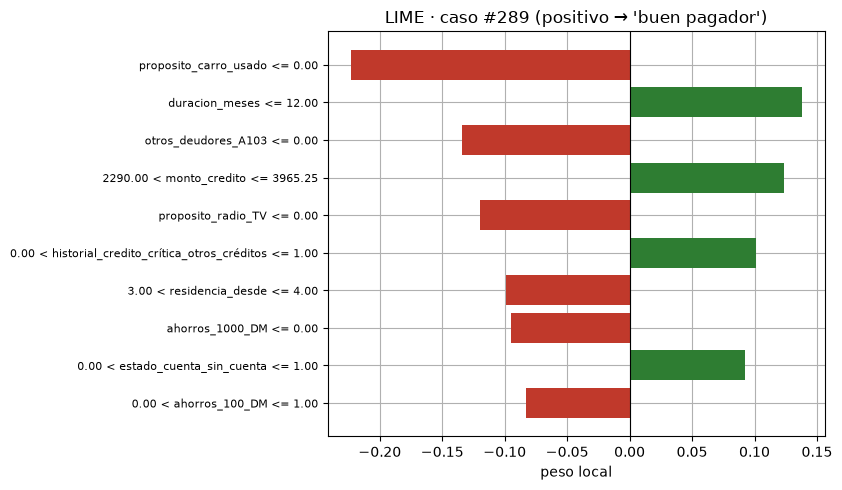

In [6]:
# Figura 1 · contribuciones locales de LIME
pares = exp.as_list()[::-1]
labels = [f for f, _ in pares]
weights = [w for _, w in pares]
colors = ["#2e7d32" if w > 0 else "#c0392b" for w in weights]

plt.figure(figsize=(8.5, 5))
plt.barh(range(len(weights)), weights, color=colors)
plt.yticks(range(len(weights)), labels, fontsize=8)
plt.axvline(0, color="k", lw=0.8)
plt.title(f"LIME · caso #{idx} (positivo → 'buen pagador')")
plt.xlabel("peso local")
plt.tight_layout(); plt.show()

### Limitaciones de LIME

LIME es agnóstico al modelo y computacionalmente económico, pero su resultado depende de decisiones sensibles: el ancho de banda $\sigma$, el muestreo aleatorio de perturbaciones y la discretización de variables continuas. En consecuencia, la explicación **no es estable**: al variar la semilla, los pesos pueden cambiar de magnitud e incluso de orden. La siguiente prueba cuantifica esa variabilidad repitiendo la explicación del mismo caso con 20 semillas.

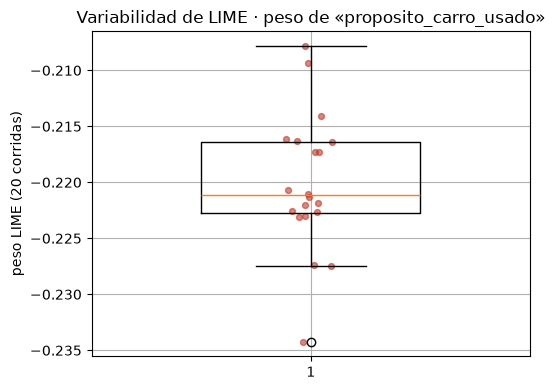

media = -0.220   desviación = 0.006   rango = [-0.234, -0.208]


In [7]:
# Figura 2 · variabilidad de LIME (misma instancia, 20 semillas)
fi = exp.as_map()[1][0][0]          # índice de la variable dominante en la primera corrida
nombre = feat[fi]
pesos = []
for s in range(20):
    e = lime.lime_tabular.LimeTabularExplainer(
        X_tr.values, feature_names=feat, class_names=["malo", "bueno"],
        mode="classification", discretize_continuous=True, random_state=s)
    ex = e.explain_instance(x0.values, model.predict_proba, num_features=len(feat))
    pesos.append(dict(ex.as_map()[1]).get(fi, 0.0))
pesos = np.array(pesos)

plt.figure(figsize=(5.5, 4))
plt.boxplot(pesos, widths=0.5)
plt.scatter(np.random.normal(1, 0.03, len(pesos)), pesos, alpha=.6, color="#c0392b", s=18)
plt.title(f"Variabilidad de LIME · peso de «{nombre}»")
plt.ylabel("peso LIME (20 corridas)")
plt.tight_layout(); plt.show()
print(f"media = {pesos.mean():+.3f}   desviación = {pesos.std():.3f}   "
      f"rango = [{pesos.min():+.3f}, {pesos.max():+.3f}]")

## Sección 3 · SHAP (valores de Shapley)

A diferencia de la aproximación local de LIME, SHAP define las contribuciones mediante un reparto con garantías teóricas, tomado de la teoría de juegos cooperativos (Shapley, 1953).

**Planteamiento.** Las $M$ variables se consideran jugadores que cooperan para producir la predicción. Para cada **coalición** $S\subseteq N=\{1,\dots,M\}$ se define un valor $v(S)$ igual a la predicción obtenida usando solo las variables de $S$. El **valor de Shapley** de la variable $i$ es su contribución marginal promediada sobre todos los órdenes de incorporación:

$$ \phi_i \;=\; \sum_{S\subseteq N\setminus\{i\}} \frac{|S|!\,(M-|S|-1)!}{M!}\,\big[\,v(S\cup\{i\}) - v(S)\,\big]. $$

El coeficiente combinatorio es la probabilidad de que, en un orden aleatorio de incorporación, los jugadores de $S$ precedan a $i$. Este reparto es el **único** que satisface simultáneamente cuatro axiomas:

| Axioma | Propiedad |
|---|---|
| **Eficiencia** | $\sum_i \phi_i = v(N)-v(\varnothing)$ |
| **Simetría** | variables intercambiables reciben igual atribución |
| **Nulidad** | una variable que no altera $v$ recibe $\phi_i=0$ |
| **Linealidad** | el valor de una combinación de juegos es la combinación de valores |

La unicidad (Shapley, 1953) es la diferencia esencial respecto a LIME.

> **Teorema 3.1 (unicidad del valor de Shapley; Shapley, 1953).** El valor de Shapley es el **único** operador $v\mapsto(\phi_1,\dots,\phi_M)$ que satisface simultáneamente los axiomas de **eficiencia**, **simetría**, **jugador nulo** y **linealidad**. (La demostración excede el alcance de este cuaderno; véase Shapley, 1953.)

### Cálculo explícito en un juego de tres variables

La fórmula de Shapley se entiende mejor calculándola a mano. Considérese un modelo con tres variables $\{x_0,x_1,x_2\}$ y una **función de valor** $v(S)$ conocida para las $2^3=8$ coaliciones (los números son ilustrativos; nótese la interacción: $v(\{x_0,x_1\})=0.45 > v(\{x_0\})+v(\{x_1\})$). Calcularemos $\phi_i$ de dos maneras equivalentes —la fórmula combinatoria y el promedio sobre los $3!=6$ órdenes— y verificaremos la **eficiencia** ($\sum_i\phi_i = v(N)-v(\varnothing)$).

In [8]:
from itertools import permutations, combinations
import math

# Función de valor v(S): predicción usando solo las variables de S (ejemplo ilustrativo)
v = {
    frozenset():        0.00,
    frozenset({0}):     0.20,
    frozenset({1}):     0.10,
    frozenset({2}):     0.05,
    frozenset({0, 1}):  0.45,   # x0 y x1 cooperan (interacción supra-aditiva)
    frozenset({0, 2}):  0.30,
    frozenset({1, 2}):  0.20,
    frozenset({0, 1, 2}): 0.70,
}
N = [0, 1, 2]; M = len(N)

def shapley_formula(i):
    rest = [j for j in N if j != i]
    phi = 0.0
    for k in range(len(rest) + 1):
        for S in combinations(rest, k):
            S = frozenset(S)
            w = math.factorial(len(S)) * math.factorial(M - len(S) - 1) / math.factorial(M)
            phi += w * (v[S | {i}] - v[S])
    return phi

def shapley_ordenes(i):
    contribs = []
    for orden in permutations(N):
        antes = frozenset(orden[:orden.index(i)])
        contribs.append(v[antes | {i}] - v[antes])
    return sum(contribs) / len(contribs)

print("variable | phi (fórmula) | phi (promedio de órdenes)")
for i in N:
    print(f"   x{i}    |   {shapley_formula(i):+.4f}    |    {shapley_ordenes(i):+.4f}")
total = sum(shapley_formula(i) for i in N)
print(f"\nSuma de phi_i      = {total:.4f}")
print(f"v(N) - v(vacío)    = {v[frozenset(N)] - v[frozenset()]:.4f}   (eficiencia: deben coincidir)")

variable | phi (fórmula) | phi (promedio de órdenes)
   x0    |   +0.3333    |    +0.3333
   x1    |   +0.2333    |    +0.2333
   x2    |   +0.1333    |    +0.1333

Suma de phi_i      = 0.7000
v(N) - v(vacío)    = 0.7000   (eficiencia: deben coincidir)


In [9]:
# Detalle: contribución marginal de x0 en cada uno de los 3! = 6 órdenes
filas = []
for orden in permutations(N):
    antes = frozenset(orden[:orden.index(0)])
    filas.append({
        "orden": " → ".join(f"x{j}" for j in orden),
        "S (antes de x0)": "{" + ", ".join(f"x{j}" for j in sorted(antes)) + "}",
        "v(S)": v[antes],
        "v(S∪{x0})": v[antes | {0}],
        "aporte de x0": v[antes | {0}] - v[antes],
    })
tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))
print(f"\nphi_0 = promedio de la última columna = {tabla['aporte de x0'].mean():+.4f}")

       orden S (antes de x0)  v(S)  v(S∪{x0})  aporte de x0
x0 → x1 → x2              {}  0.00       0.20          0.20
x0 → x2 → x1              {}  0.00       0.20          0.20
x1 → x0 → x2            {x1}  0.10       0.45          0.35
x1 → x2 → x0        {x1, x2}  0.20       0.70          0.50
x2 → x0 → x1            {x2}  0.05       0.30          0.25
x2 → x1 → x0        {x1, x2}  0.20       0.70          0.50

phi_0 = promedio de la última columna = +0.3333


La coincidencia entre ambas columnas confirma que la fórmula combinatoria equivale al promedio de las contribuciones marginales sobre todos los órdenes de incorporación, y que la suma de las atribuciones reconstruye el valor total (eficiencia). **SHAP traslada este cálculo al modelo** definiendo $v(S)=\mathbb E[f(X)\mid X_S=x_S]$. En el modelo real hay $M$ variables, de modo que el promedio recorre $2^M$ coaliciones; **TreeSHAP** lo resuelve de forma exacta y eficiente para árboles, que es lo que se aplica a continuación.

### Especialización a modelos de aprendizaje (SHAP)

Lundberg & Lee (2017) instancian el valor de coalición como una **esperanza condicional** del modelo:

$$ v(S) \;=\; \mathbb E\big[\,f(X)\;\big|\;X_S = x_S\,\big]. $$

De ahí se derivan tres propiedades: **exactitud local** ($f(x)=\phi_0+\sum_i\phi_i$, con $\phi_0=\mathbb E[f(X)]$), **ausencia** (variable no presente → aporte nulo) y **consistencia** (si un modelo incrementa su dependencia de una variable, su $\phi$ no decrece).

El cálculo exacto requiere $2^M$ evaluaciones. Dos estimadores lo hacen viable:

- **KernelSHAP** (agnóstico): aproxima los $\phi_i$ mediante una regresión lineal ponderada sobre coaliciones muestreadas, con el núcleo de Shapley
$$ \pi(S) \;=\; \frac{M-1}{\binom{M}{|S|}\,|S|\,(M-|S|)} . $$
Resolver esa regresión recupera los valores de Shapley; en este sentido SHAP unifica LIME y Shapley (LIME con el núcleo y la pérdida adecuados equivale a KernelSHAP).
- **TreeSHAP** (específico para árboles): los calcula de forma **exacta** en tiempo polinómico. Dado que el modelo es XGBoost, se utiliza este estimador.

A continuación se calculan los valores y se verifica la aditividad sobre los datos.

> **Definición 3.2 (función de valor de SHAP).** SHAP instancia el juego con la **esperanza condicional** del modelo, $v(S)=\mathbb E\big[f(X)\mid X_S=x_S\big]$, y toma $\phi_0=v(\varnothing)=\mathbb E[f(X)]$.

> **Proposición 3.2 (exactitud local).** Con esa función de valor, los valores de Shapley reconstruyen exactamente la predicción:
> $$ f(x)=\phi_0+\sum_{i=1}^M \phi_i. $$
>
> **Demostración.** Por el axioma de **eficiencia**, $\sum_{i=1}^M\phi_i=v(N)-v(\varnothing)$. Ahora $v(N)=\mathbb E[f(X)\mid X=x]=f(x)$ (todas las variables fijadas a $x$) y $v(\varnothing)=\mathbb E[f(X)]=\phi_0$. Por tanto $\sum_i\phi_i=f(x)-\phi_0$, es decir $f(x)=\phi_0+\sum_i\phi_i$. $\blacksquare$ (La celda siguiente lo verifica numéricamente.)

> **Definición 3.3 (núcleo de Shapley, KernelSHAP).** KernelSHAP estima los $\phi_i$ mediante una regresión lineal ponderada sobre coaliciones $z'\in\{0,1\}^M$ con el **núcleo de Shapley**
> $$ \pi(z')=\frac{M-1}{\binom{M}{|z'|}\,|z'|\,(M-|z'|)}. $$
>
> **Observación 3.1 (unificación LIME–SHAP).** Con el núcleo de la Definición 3.3 y pérdida cuadrática, la regresión ponderada de la Proposición 2.1 **recupera exactamente los valores de Shapley** (Lundberg & Lee, 2017). LIME y SHAP son, pues, la misma construcción con distinta elección de $\pi$: SHAP la fija para garantizar los axiomas; LIME la deja libre y pierde la unicidad.

In [10]:
# TreeSHAP: valores de Shapley exactos para árboles
explainer = shap.TreeExplainer(model)
sv = explainer(X_te)                       # objeto Explanation (n x M)

# Verificación de aditividad (exactitud local) en el caso #idx
phi0 = float(sv.base_values[idx])
suma = phi0 + float(sv.values[idx].sum())
margin = float(model.predict(X_te, output_margin=True)[idx])   # f(x) en log-odds
print(f"phi_0  = E[f(X)]              = {phi0:+.4f}")
print(f"phi_0 + sum_i phi_i          = {suma:+.4f}")
print(f"f(x)   (log-odds del modelo) = {margin:+.4f}")
print(f"|diferencia|                 = {abs(suma - margin):.2e}   (aditividad exacta)")

phi_0  = E[f(X)]              = +0.8543
phi_0 + sum_i phi_i          = -0.0055
f(x)   (log-odds del modelo) = -0.0055
|diferencia|                 = 3.20e-07   (aditividad exacta)


### KernelSHAP recupera los mismos valores

El texto afirmó que KernelSHAP —una regresión lineal ponderada sobre coaliciones muestreadas con el núcleo de Shapley— recupera los valores de Shapley. Se comprueba calculando **KernelSHAP** (agnóstico, aproximado) y **TreeSHAP** (exacto) en espacio de **probabilidad** sobre los mismos casos y contrastando ambas atribuciones.

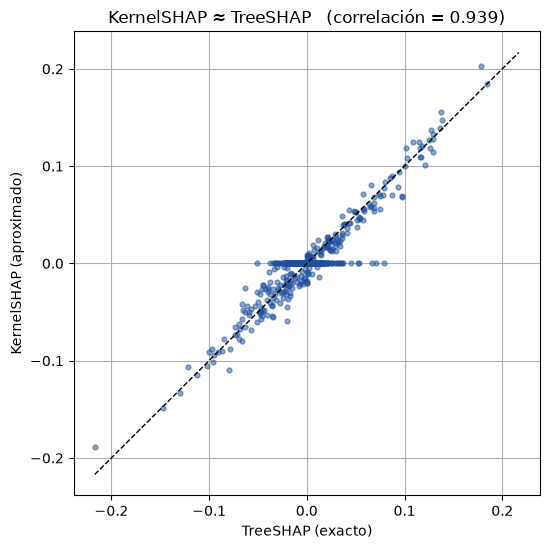

In [11]:
# KernelSHAP (agnóstico) frente a TreeSHAP (exacto), ambos en probabilidad
fondo = shap.sample(X_tr, 40, random_state=RANDOM_STATE)
f_prob = lambda data: model.predict_proba(data)[:, 1]
Xs = X_te.iloc[:25]

ke = shap.KernelExplainer(f_prob, fondo)
sv_kernel = np.asarray(ke.shap_values(Xs, nsamples=150, silent=True))
te_prob = shap.TreeExplainer(model, data=fondo, model_output="probability")
sv_tree = np.asarray(te_prob.shap_values(Xs))

a = sv_kernel.ravel(); b = sv_tree.ravel()
lim = float(np.abs(np.r_[a, b]).max())
plt.figure(figsize=(5.6, 5.6))
plt.scatter(b, a, s=12, alpha=.5, color="#1f4e9c")
plt.plot([-lim, lim], [-lim, lim], "k--", lw=1)
plt.xlabel("TreeSHAP (exacto)"); plt.ylabel("KernelSHAP (aproximado)")
plt.title(f"KernelSHAP ≈ TreeSHAP   (correlación = {np.corrcoef(a, b)[0, 1]:.3f})")
plt.tight_layout(); plt.show()

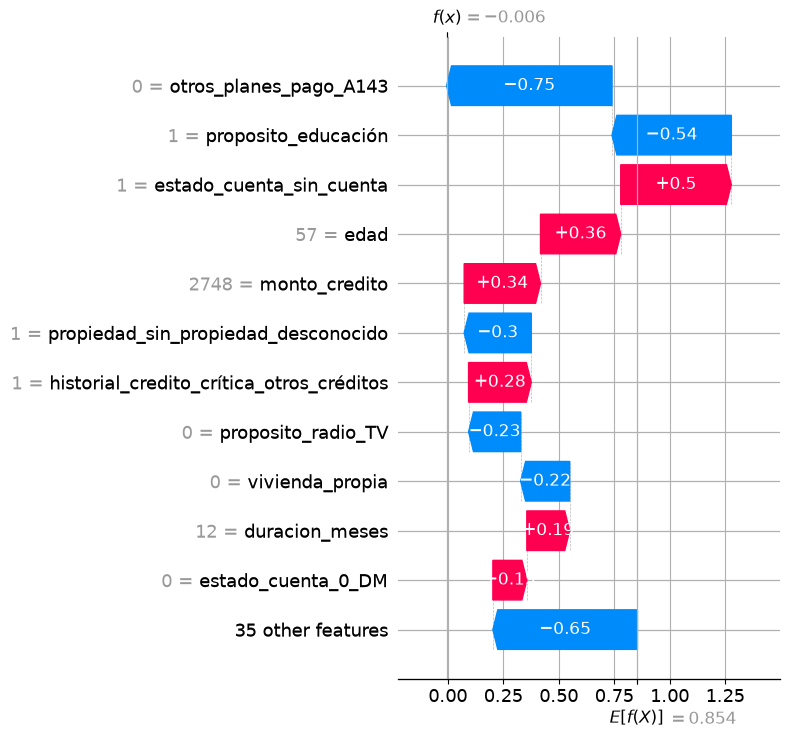

In [12]:
# Figura 3 · waterfall: descomposición aditiva de la predicción del caso #idx
shap.plots.waterfall(sv[idx], max_display=12, show=False)
plt.tight_layout(); plt.show()

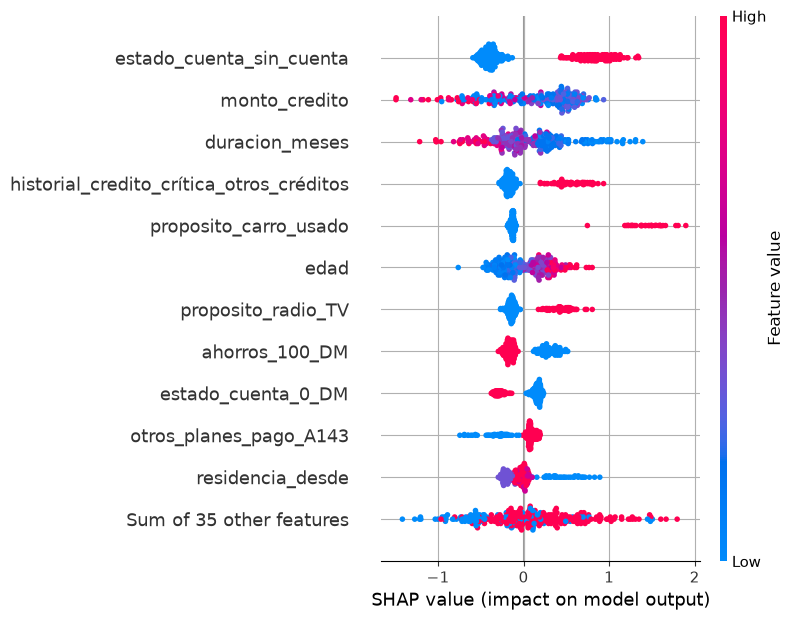

In [13]:
# Figura 4 · beeswarm: atribuciones a nivel global (un punto por caso)
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.tight_layout(); plt.show()

### Cómo leer estos gráficos

- **Waterfall (un caso).** Parte del valor base $\phi_0=\mathbb E[f(X)]$ y suma las contribuciones $\phi_i$ una a una hasta alcanzar $f(x)$. La longitud de cada barra es $|\phi_i|$ y su color indica la dirección del aporte; por la exactitud local, las barras suman exactamente $f(x)-\phi_0$.
- **Beeswarm (global).** Cada punto es un caso y cada fila una variable, ordenadas por importancia media $\frac1n\sum_n|\phi_i|$. La posición horizontal es el valor SHAP (dirección y magnitud) y el color, el valor de la variable; revela, por ejemplo, si valores altos de una variable empujan sistemáticamente hacia una clase.
- **Barra (global).** Resume el beeswarm en una cifra por variable: la media de $|\phi_i|$. Es la medida de importancia global **coherente** con las atribuciones locales (a diferencia de otras importancias *ad hoc*).

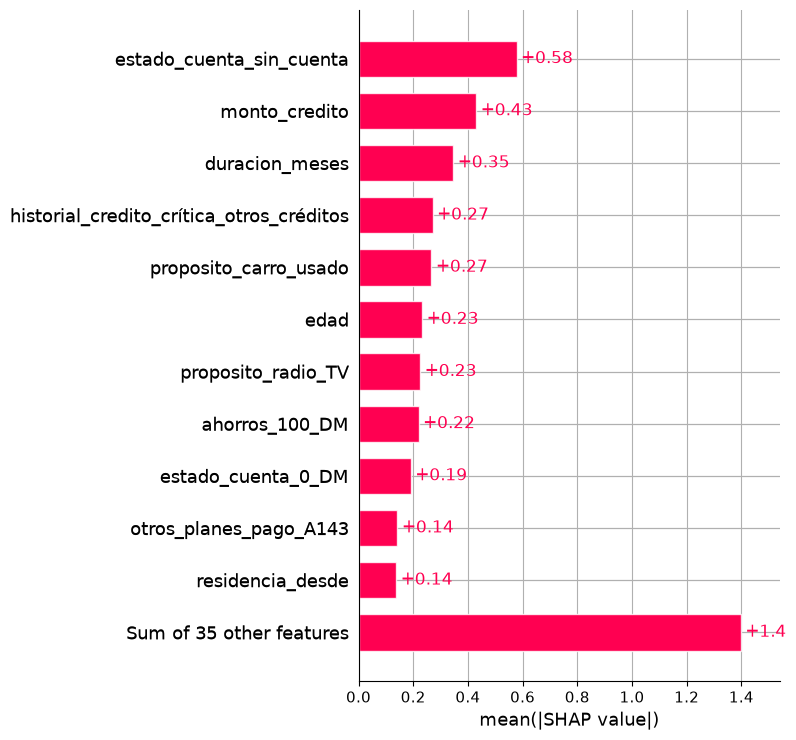

In [14]:
# Figura · importancia global: media de |valor SHAP| por variable
shap.plots.bar(sv, max_display=12, show=False)
plt.tight_layout(); plt.show()

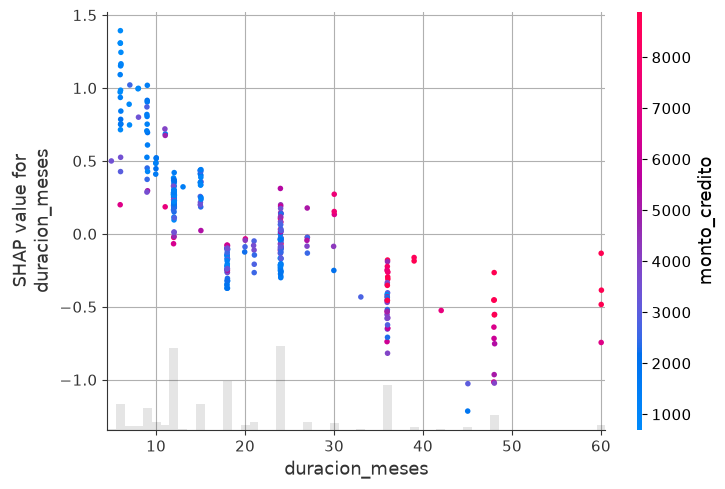

In [15]:
# Figura 5 · dependencia: aporte de la duración del crédito según su valor
shap.plots.scatter(sv[:, "duracion_meses"], color=sv[:, "monto_credito"], show=False)
plt.tight_layout(); plt.show()

El *beeswarm* resume las atribuciones de todo el conjunto: las variables se ordenan por influencia media; la posición horizontal indica la dirección del aporte y el color, el valor de la variable. El gráfico de dependencia muestra cómo la contribución de la *duración del crédito* varía con su magnitud y su interacción con el *monto*, información que una única medida escalar de importancia no captura. Todas estas atribuciones son fieles al modelo y de naturaleza asociacional.

## Sección 4 · Comparación SHAP–LIME

Ambos métodos producen atribuciones aditivas locales; difieren en garantías y costo:

| Criterio | LIME | SHAP (Tree/Kernel) |
|---|---|---|
| Fundamento | sustituto lineal local | valores de Shapley (axiomático) |
| Garantías formales | ninguna | eficiencia, simetría, nulidad, consistencia |
| Aditividad exacta | aproximada | sí (exactitud local) |
| Estabilidad | baja (sensible a $\sigma$ y semilla) | alta (TreeSHAP determinista) |
| Costo | bajo | alto en general; bajo para árboles |
| Limitación | dependencia del vecindario | la esperanza condicional mezcla correlaciones |

La siguiente figura contrasta, para el mismo caso, las atribuciones de ambos métodos. Las escalas difieren (SHAP en *log-odds*; LIME en probabilidad), por lo que el interés está en la coincidencia de signo y orden, no en la magnitud.

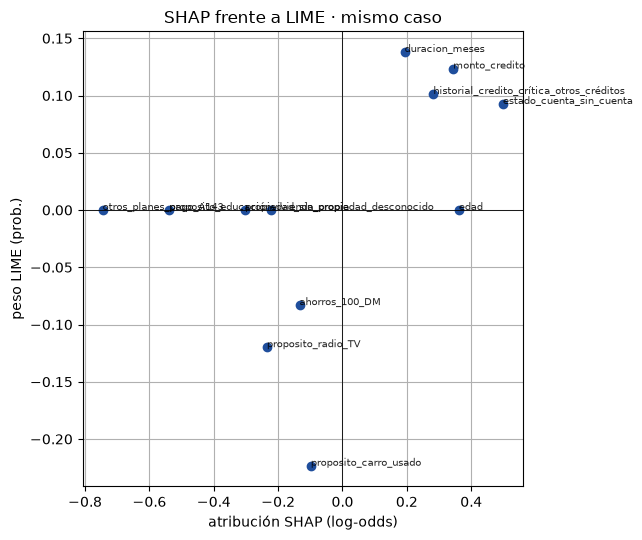

Concordancia esperable en el signo; divergencia en magnitud por las distintas escalas.


In [16]:
# Figura 6 · SHAP frente a LIME para el mismo caso
shap_i = pd.Series(sv.values[idx], index=feat)
lime_i = pd.Series(0.0, index=feat)
for j, w in exp.as_map()[1]:
    lime_i.iloc[j] = w
comp = pd.DataFrame({"SHAP": shap_i, "LIME": lime_i})
comp = comp.loc[comp.abs().sum(axis=1).sort_values(ascending=False).index[:12]]

plt.figure(figsize=(6.5, 5.5))
plt.scatter(comp["SHAP"], comp["LIME"], color="#1f4e9c")
for n, r in comp.iterrows():
    plt.annotate(n, (r["SHAP"], r["LIME"]), fontsize=7, alpha=.85)
plt.axhline(0, color="k", lw=.6); plt.axvline(0, color="k", lw=.6)
plt.xlabel("atribución SHAP (log-odds)"); plt.ylabel("peso LIME (prob.)")
plt.title("SHAP frente a LIME · mismo caso")
plt.tight_layout(); plt.show()
print("Concordancia esperable en el signo; divergencia en magnitud por las distintas escalas.")

### Determinismo: una diferencia práctica

Las garantías de SHAP tienen una consecuencia operativa: **TreeSHAP es determinista** (misma entrada → misma atribución), mientras que **LIME varía** entre corridas por el muestreo de perturbaciones. Se cuantifica sobre el caso #idx.

Variación máxima de SHAP entre 5 corridas : 2.98e-08  (determinista)


Variación de LIME para «proposito_carro_usado» (20 corridas): 0.006  (estocástico)


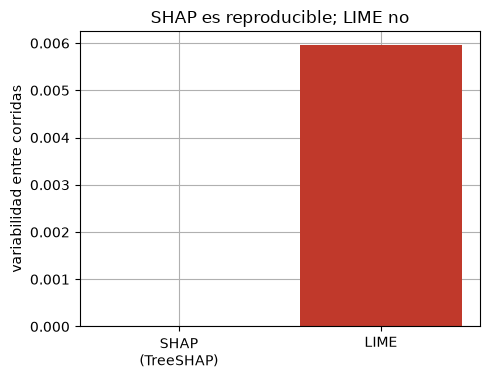

In [17]:
# SHAP es determinista; LIME no
corridas_shap = [shap.TreeExplainer(model)(X_te.iloc[[idx]]).values[0] for _ in range(5)]
shap_std = float(np.std(corridas_shap, axis=0).max())
print(f"Variación máxima de SHAP entre 5 corridas : {shap_std:.2e}  (determinista)")
print(f"Variación de LIME para «{nombre}» (20 corridas): {pesos.std():.3f}  (estocástico)")

plt.figure(figsize=(5, 3.9))
plt.bar(["SHAP\n(TreeSHAP)", "LIME"], [shap_std, pesos.std()], color=["#2e7d32", "#c0392b"])
plt.ylabel("variabilidad entre corridas"); plt.title("SHAP es reproducible; LIME no")
plt.tight_layout(); plt.show()

## Sección 5 · Alcance y límite causal

SHAP y LIME explican, con distinta fidelidad, el comportamiento del modelo $f$ sobre la **distribución observada**. De ello se siguen dos restricciones:

1. **Atribución ≠ efecto causal.** Una atribución $\phi$ elevada para `estado_cuenta = sin cuenta` no implica que intervenir sobre esa variable (abrir una cuenta) modifique la probabilidad de pago. Corresponde al nivel asociacional (peldaño 1 de la escalera de Pearl).
2. **La esperanza condicional incorpora correlaciones.** En $v(S)=\mathbb E[f(X)\mid X_S=x_S]$, marginalizar sobre el resto emplea la distribución observacional, donde las variables están correlacionadas. Por ello SHAP puede atribuir importancia a variables que solo son *proxy* de la causa real (Aas et al., 2021; Janzing et al., 2020).

La corrección consiste en sustituir el condicionamiento observacional $\mathbb E[f\mid X_S]$ por uno **intervencional** $\mathbb E[f\mid do(X_S)]$ —el SHAP causal / *do-SHAP* del cuaderno 04—. Definir ese operador $do(\cdot)$ requiere el formalismo causal de la Sección 2.

### Demostración: el SHAP observacional reparte importancia a un *proxy*

Para hacer tangible el límite causal, se construye un caso con **verdad conocida**: $x_1$ es la única causa de $y$, y $x_2=x_1+\text{ruido}$ es un *proxy* correlacionado con $x_1$ pero **sin efecto propio**. Como $v(S)=\mathbb E[f(X)\mid X_S]$ emplea la distribución observacional, SHAP atribuye importancia también a $x_2$. Este es exactamente el problema que el cuaderno 04 corrige sustituyendo el condicionamiento por el operador $do(\cdot)$.

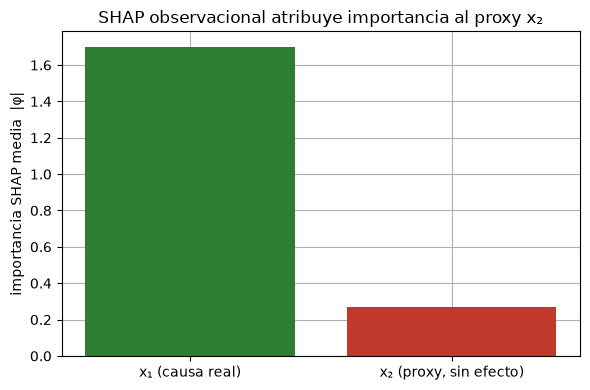

importancia media |φ|:  x1 = 1.700   x2 = 0.272   (x2 NO tiene efecto causal sobre y)


In [18]:
# Verdad conocida: solo x1 causa y; x2 es un proxy correlacionado sin efecto propio
n = 4000
x1 = rng.normal(0, 1, n)
x2 = x1 + rng.normal(0, 0.3, n)              # proxy de x1
prob = 1 / (1 + np.exp(-(2.0 * x1)))          # y depende SOLO de x1
yp = (rng.uniform(size=n) < prob).astype(int)
Xp = pd.DataFrame({"x1_causa": x1, "x2_proxy": x2})

mp = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                   eval_metric="logloss", random_state=RANDOM_STATE).fit(Xp, yp)
svp = shap.TreeExplainer(mp)(Xp)
imp = np.abs(svp.values).mean(axis=0)

plt.figure(figsize=(6, 4))
plt.bar(["x₁ (causa real)", "x₂ (proxy, sin efecto)"], imp, color=["#2e7d32", "#c0392b"])
plt.ylabel("importancia SHAP media  |φ|")
plt.title("SHAP observacional atribuye importancia al proxy x₂")
plt.tight_layout(); plt.show()
print(f"importancia media |φ|:  x1 = {imp[0]:.3f}   x2 = {imp[1]:.3f}   "
      f"(x2 NO tiene efecto causal sobre y)")

## Síntesis

- **LIME**: sustituto lineal local (mínimos cuadrados ponderados por proximidad); flexible pero inestable.
- **SHAP**: valores de Shapley (reparto axiomático único); estable y aditivo, exacto para árboles mediante TreeSHAP.
- Ambos operan en el nivel asociacional; la esperanza condicional de SHAP mezcla, además, correlaciones entre variables.

**Continuación.** El cuaderno 03 aborda las explicaciones **globales** (importancia por permutación, PDP/ALE) y las **explicaciones contrafactuales** (DiCE), que responden a la pregunta del cambio mínimo necesario para alterar una decisión.

*(El diagrama de flujo del cuaderno se muestra al inicio.)*

## Ejemplos complementarios

Tres ejemplos desarrollados sobre el modelo y las atribuciones ya calculadas.

### Ejemplo 1 · Efecto del ancho de banda de LIME

LIME usa por defecto $\sigma=0.75\sqrt{M}$. Se comparan las explicaciones del **mismo** caso con un vecindario estrecho y uno amplio: el ancho de banda cambia qué tan local es la aproximación y, por tanto, las atribuciones.

In [19]:
for kw, etiqueta in [(1.0, "estrecho"), (25.0, "amplio")]:
    e = lime.lime_tabular.LimeTabularExplainer(
        X_tr.values, feature_names=feat, class_names=["malo", "bueno"],
        mode="classification", discretize_continuous=True,
        random_state=RANDOM_STATE, kernel_width=kw)
    ex = e.explain_instance(x0.values, model.predict_proba, num_features=5)
    print(f"\nvecindario {etiqueta} (kernel_width={kw}):")
    for f, w in ex.as_list():
        print(f"   {w:+.3f}   {f}")


vecindario estrecho (kernel_width=1.0):
   -0.080   proposito_educación > 0.00
   -0.074   3.00 < residencia_desde <= 4.00
   -0.071   proposito_radio_TV <= 0.00
   +0.056   duracion_meses <= 12.00
   -0.046   proposito_carro_usado <= 0.00



vecindario amplio (kernel_width=25.0):
   -0.226   proposito_carro_usado <= 0.00
   +0.139   duracion_meses <= 12.00
   -0.121   proposito_radio_TV <= 0.00
   +0.117   2290.00 < monto_credito <= 3965.25
   -0.103   3.00 < residencia_desde <= 4.00


### Ejemplo 2 · Importancia global: SHAP frente a permutación

Se compara la importancia media de SHAP, $\frac1n\sum_n|\phi_i|$, con la importancia por permutación sobre el mismo modelo. Aunque sus escalas difieren, deben coincidir en el **orden**.

C:\Users\cizai\AppData\Local\Temp\ipykernel_41300\3420688802.py:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  top = imp_df.loc[imp_df.abs().sum(1).sort_values(ascending=False).index[:10]]


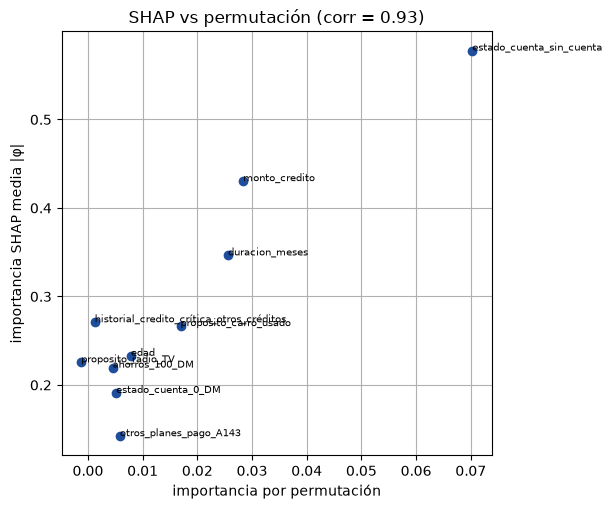

In [20]:
from sklearn.inspection import permutation_importance
shap_imp = np.abs(sv.values).mean(axis=0)
pimp = permutation_importance(model, X_te, y_te, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE).importances_mean
imp_df = pd.DataFrame({"SHAP": shap_imp, "permutacion": pimp}, index=feat)
top = imp_df.loc[imp_df.abs().sum(1).sort_values(ascending=False).index[:10]]
plt.figure(figsize=(6.2, 5.2))
plt.scatter(top["permutacion"], top["SHAP"], color="#1f4e9c")
for n, r in top.iterrows():
    plt.annotate(n, (r["permutacion"], r["SHAP"]), fontsize=7)
plt.xlabel("importancia por permutación"); plt.ylabel("importancia SHAP media |φ|")
plt.title(f"SHAP vs permutación (corr = {top.corr().iloc[0, 1]:.2f})")
plt.tight_layout(); plt.show()

### Ejemplo 3 · Aditividad en otro caso

Se verifica la exactitud local $\phi_0+\sum_i\phi_i=f(x)$ para un caso distinto al analizado en la Sección 3.

In [21]:
k = 7
suma_k = float(sv.base_values[k]) + float(sv.values[k].sum())
margin_k = float(model.predict(X_te, output_margin=True)[k])
print(f"caso #{k}:  phi0 + sum(phi_i) = {suma_k:+.4f}   "
      f"f(x) = {margin_k:+.4f}   |diferencia| = {abs(suma_k - margin_k):.2e}")

caso #7:  phi0 + sum(phi_i) = -0.8226   f(x) = -0.8226   |diferencia| = 9.54e-07


### Ejemplo 4 · Shapley exacto (fuerza bruta) frente a TreeSHAP

Sobre un submodelo de **tres** variables se calculan los valores de Shapley por enumeración directa de las $2^3$ coaliciones (con $v(S)=\mathbb E[f(X)\mid do(X_S)]$ estimado sobre un fondo) y se contrastan con TreeSHAP.

In [22]:
from itertools import combinations
import math
tres = ["duracion_meses", "monto_credito", "edad"]
Xt3, Xte3 = X_tr[tres].astype(float), X_te[tres].astype(float)
m3 = XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.1,
                   eval_metric="logloss", random_state=RANDOM_STATE).fit(Xt3, y_tr)
fondo3 = Xt3.sample(100, random_state=RANDOM_STATE).to_numpy()
xq = Xte3.iloc[0].to_numpy()

def v(S):
    B = fondo3.copy()
    for j in S:
        B[:, j] = xq[j]
    return m3.predict(B, output_margin=True).mean()

N = [0, 1, 2]; M = 3
def phi(i):
    rest = [j for j in N if j != i]; tot = 0.0
    for k in range(len(rest) + 1):
        for Sc in combinations(rest, k):
            S = list(Sc)
            w = math.factorial(len(S)) * math.factorial(M - len(S) - 1) / math.factorial(M)
            tot += w * (v(S + [i]) - v(S))
    return tot

phi_bruta = [phi(i) for i in N]
ex3 = shap.TreeExplainer(m3, data=fondo3, feature_perturbation="interventional")(Xte3.iloc[[0]])
print("variable        | Shapley fuerza bruta | TreeSHAP")
for i, name in enumerate(tres):
    print(f"  {name:14s} |     {phi_bruta[i]:+.4f}          |  {float(ex3.values[0][i]):+.4f}")

variable        | Shapley fuerza bruta | TreeSHAP
  duracion_meses |     +0.2329          |  +0.2329
  monto_credito  |     +0.7452          |  +0.7452
  edad           |     +0.1181          |  +0.1181


### Ejemplo 5 · Convergencia de KernelSHAP según el número de coaliciones

KernelSHAP aproxima los valores exactos; el error decae al aumentar `nsamples` (coaliciones muestreadas). Se mide frente a TreeSHAP.

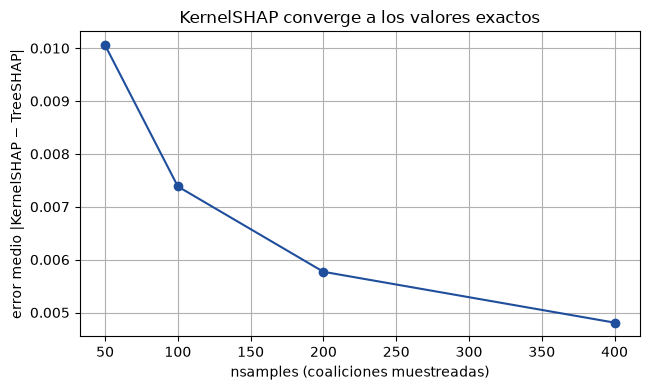

error medio por nsamples: [np.float64(0.0101), np.float64(0.0074), np.float64(0.0058), np.float64(0.0048)]


In [23]:
fondoK = shap.sample(X_tr, 40, random_state=RANDOM_STATE)
keK = shap.KernelExplainer(lambda d: model.predict_proba(d)[:, 1], fondoK)
teK = shap.TreeExplainer(model, data=fondoK, model_output="probability")
ref = np.asarray(teK.shap_values(X_te.iloc[:10])).ravel()
ns = [50, 100, 200, 400]; errs = []
for nsm in ns:
    apx = np.asarray(keK.shap_values(X_te.iloc[:10], nsamples=nsm, silent=True)).ravel()
    errs.append(np.abs(apx - ref).mean())
plt.figure(figsize=(6.6, 4))
plt.plot(ns, errs, "-o", color="#1f4e9c")
plt.xlabel("nsamples (coaliciones muestreadas)")
plt.ylabel("error medio |KernelSHAP − TreeSHAP|")
plt.title("KernelSHAP converge a los valores exactos")
plt.tight_layout(); plt.show()
print("error medio por nsamples:", [round(e, 4) for e in errs])

## Referencias (APA 7)

- Aas, K., Jullum, M., & Løland, A. (2021). Explaining individual predictions when features are dependent: More accurate approximations to Shapley values. *Artificial Intelligence, 298*, 103502.
- Janzing, D., Minorics, L., & Blöbaum, P. (2020). Feature relevance quantification in explainable AI: A causal problem. *AISTATS*, 2907–2916.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*.
- Molnar, C. (2022). *Interpretable machine learning: A guide for making black box models explainable* (2nd ed.).
- Ng, W. Y., Wang, L. R., Liu, S., & Fan, X. (2025). *Causal SHAP: Feature attribution with dependency awareness through causal discovery* [Preprint]. arXiv:2509.00846.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. *KDD*, 1135–1144.
- Shapley, L. S. (1953). A value for n-person games. In *Contributions to the Theory of Games II* (pp. 307–317). Princeton University Press.